# Wardrobe pipeline (v2)

This is the **new notebook version** — use this file for ongoing work. The older `extract_metadata.ipynb` remains as-is for reference.

**Setup:** `.env` with `OPENAI_API_KEY`, `OPENROUTER_API_KEY`, or Anthropic (`ANTHROPIC_AUTH_TOKEN` **or** `ANTHROPIC_API_KEY`). Install: `pip install -r requirements.txt`

**Notebook layout**
1. **Helpers** — imports, `ROOT`, image/JSON utilities, OpenRouter image chat, text LLM client.
2. **Vision** — `EXTRACTION_SYSTEM` + `extract_clothing_metadata`.
3. **Single-image demo** — config → display → run.
4. **Batch** — `/images` → `/metadata`.
5. **Outfits (text)** — `OUTFIT_SYSTEM` + `suggest_outfit_combinations` → run (supports layered `top` as string or array).
6. **Preview prompt** — `outfit_image_prompt_for_generation` (person vs generic model).
7. **Preview gen** — `generate_outfit_preview_images` → run (optional `PERSON_IMAGE_PATH`).


## Helper Functions

In [1]:
from __future__ import annotations

import base64
import contextlib
import json
import mimetypes
import os
import urllib.error
import urllib.request
from pathlib import Path
from typing import Any, Literal

from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

def _image_bytes_and_mime(path: Path) -> tuple[bytes, str]:
    raw = path.read_bytes()
    mime, _ = mimetypes.guess_type(path.name)
    if not mime:
        mime = "image/jpeg"
    return raw, mime


def _data_url(path: Path) -> str:
    raw, mime = _image_bytes_and_mime(path)
    b64 = base64.standard_b64encode(raw).decode("ascii")
    return f"data:{mime};base64,{b64}"


def _parse_json_loose(text: str) -> dict[str, Any]:
    """Handle optional ```json fences (e.g. Anthropic)."""
    text = text.strip()
    if text.startswith("```"):
        lines = text.split("\n")
        lines = lines[1:]
        if lines and lines[0].strip().lower().startswith("json"):
            lines = lines[1:]
        while lines and lines[-1].strip() == "```":
            lines.pop()
        text = "\n".join(lines)
    return json.loads(text)


def _openai_like_client(provider: Literal["openai", "openrouter"]) -> OpenAI:
    if provider == "openai":
        return OpenAI(api_key=os.environ["OPENAI_API_KEY"])
    default_headers = {
        "X-Title": os.environ.get("OPENROUTER_APP_TITLE", "Fashion metadata extraction"),
    }
    referer = os.environ.get("OPENROUTER_HTTP_REFERER")
    if referer:
        default_headers["HTTP-Referer"] = referer
    return OpenAI(
        api_key=os.environ["OPENROUTER_API_KEY"],
        base_url="https://openrouter.ai/api/v1",
        default_headers=default_headers,
    )


def text_completion_json_object(
    *,
    provider: Literal["openai", "openrouter", "anthropic"],
    model: str,
    system: str,
    user: str,
    temperature: float = 0.3,
) -> dict[str, Any]:
    """Chat completion that returns a single JSON object (not a bare array)."""
    if provider in ("openai", "openrouter"):
        client = _openai_like_client(provider)
        r = client.chat.completions.create(
            model=model,
            temperature=temperature,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": user},
            ],
        )
        text = r.choices[0].message.content
        if not text:
            raise ValueError("Empty response from text model")
        return json.loads(text)

    if provider == "anthropic":
        import anthropic

        oauth = os.environ.get("ANTHROPIC_AUTH_TOKEN")
        api_key = os.environ.get("ANTHROPIC_API_KEY")
        if oauth and api_key:
            raise ValueError(
                "Set only one of ANTHROPIC_AUTH_TOKEN (OAuth) or ANTHROPIC_API_KEY, not both."
            )
        if oauth:
            client = anthropic.Anthropic(auth_token=oauth)
        elif api_key:
            client = anthropic.Anthropic(api_key=api_key)
        else:
            raise ValueError(
                "Set ANTHROPIC_AUTH_TOKEN (OAuth bearer token) or ANTHROPIC_API_KEY in the environment."
            )
        message = client.messages.create(
            model=model,
            max_tokens=4096,
            temperature=temperature,
            system=system + "\n\nReturn ONLY valid JSON, no markdown fences.",
            messages=[{"role": "user", "content": user}],
        )
        parts: list[str] = []
        for block in message.content:
            if block.type == "text":
                parts.append(block.text)
        combined = "".join(parts).strip()
        if not combined:
            raise ValueError("Empty response from text model")
        return _parse_json_loose(combined)

    raise ValueError(f"Unknown provider: {provider}")


def load_wardrobe_from_metadata_dir(metadata_dir: Path) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for p in sorted(metadata_dir.glob("*.json")):
        rows.append(json.loads(p.read_text(encoding="utf-8")))
    return rows


def _decode_data_url_to_png_bytes(data_url: str) -> bytes:
    """Decode data:image/...;base64,... to raw bytes."""
    if not data_url.startswith("data:"):
        raise ValueError(f"Expected a data: URL, got {data_url[:48]!r}…")
    comma = data_url.find(",")
    if comma < 0:
        raise ValueError("Malformed data URL")
    b64 = data_url[comma + 1 :]
    return base64.standard_b64decode(b64)



def _openrouter_chat_image_generation(
    *,
    model: str,
    reference_image_paths: list[Path],
    prompt: str,
    image_config: dict[str, Any] | None = None,
) -> bytes:
    """OpenRouter Gemini image models: ``/v1/chat/completions`` + ``modalities``."""
    if not reference_image_paths:
        raise ValueError("reference_image_paths is empty")
    key = os.environ["OPENROUTER_API_KEY"]
    headers: dict[str, str] = {
        "Authorization": f"Bearer {key}",
        "Content-Type": "application/json",
        "X-Title": os.environ.get("OPENROUTER_APP_TITLE", "Fashion outfit preview"),
    }
    referer = os.environ.get("OPENROUTER_HTTP_REFERER")
    if referer:
        headers["HTTP-Referer"] = referer

    image_parts = [{"type": "image_url", "image_url": {"url": _data_url(p)}} for p in reference_image_paths]
    payload: dict[str, Any] = {
        "model": model,
        "messages": [
            {
                "role": "user",
                "content": [{"type": "text", "text": prompt}, *image_parts],
            }
        ],
        "modalities": ["image", "text"],
    }
    if image_config:
        payload["image_config"] = image_config

    data = json.dumps(payload, ensure_ascii=False).encode("utf-8")
    req = urllib.request.Request(
        "https://openrouter.ai/api/v1/chat/completions",
        data=data,
        headers=headers,
        method="POST",
    )
    try:
        with urllib.request.urlopen(req, timeout=300) as resp:
            body = json.loads(resp.read().decode("utf-8"))
    except urllib.error.HTTPError as e:
        err = e.read().decode("utf-8", errors="replace")
        raise RuntimeError(f"OpenRouter HTTP {e.code}: {err[:4000]}") from e

    if body.get("error"):
        raise RuntimeError(f"OpenRouter API error: {body['error']}")
    msg = (body.get("choices") or [{}])[0].get("message") or {}
    images = msg.get("images") or []
    if not images:
        c = (msg.get("content") or "")[:800]
        raise ValueError(
            "No images in OpenRouter response (need image output + modalities). "
            f"message_keys={list(msg.keys())!r} content_preview={c!r}"
        )
    first = images[0]
    url: str | None = None
    if isinstance(first.get("image_url"), dict):
        url = first["image_url"].get("url")
    if not url:
        url = first.get("url")
    if not url:
        raise ValueError(f"Unexpected image entry: {first!r}")
    if url.startswith("data:"):
        return _decode_data_url_to_png_bytes(url)
    with urllib.request.urlopen(url, timeout=120) as r:
        return r.read()


def project_root() -> Path:
    here = Path.cwd().resolve()
    if (here / "notebooks").is_dir() and here.name == "notebooks":
        return here.parent
    return here


def ensure_project_dirs(root: Path) -> None:
    """Create standard project folders if missing (idempotent)."""
    (root / "images").mkdir(parents=True, exist_ok=True)
    (root / "metadata").mkdir(parents=True, exist_ok=True)
    (root / "outputs").mkdir(parents=True, exist_ok=True)
    (root / "outputs" / "outfit_previews").mkdir(parents=True, exist_ok=True)


ROOT = project_root()
ensure_project_dirs(ROOT)



## Image Grid

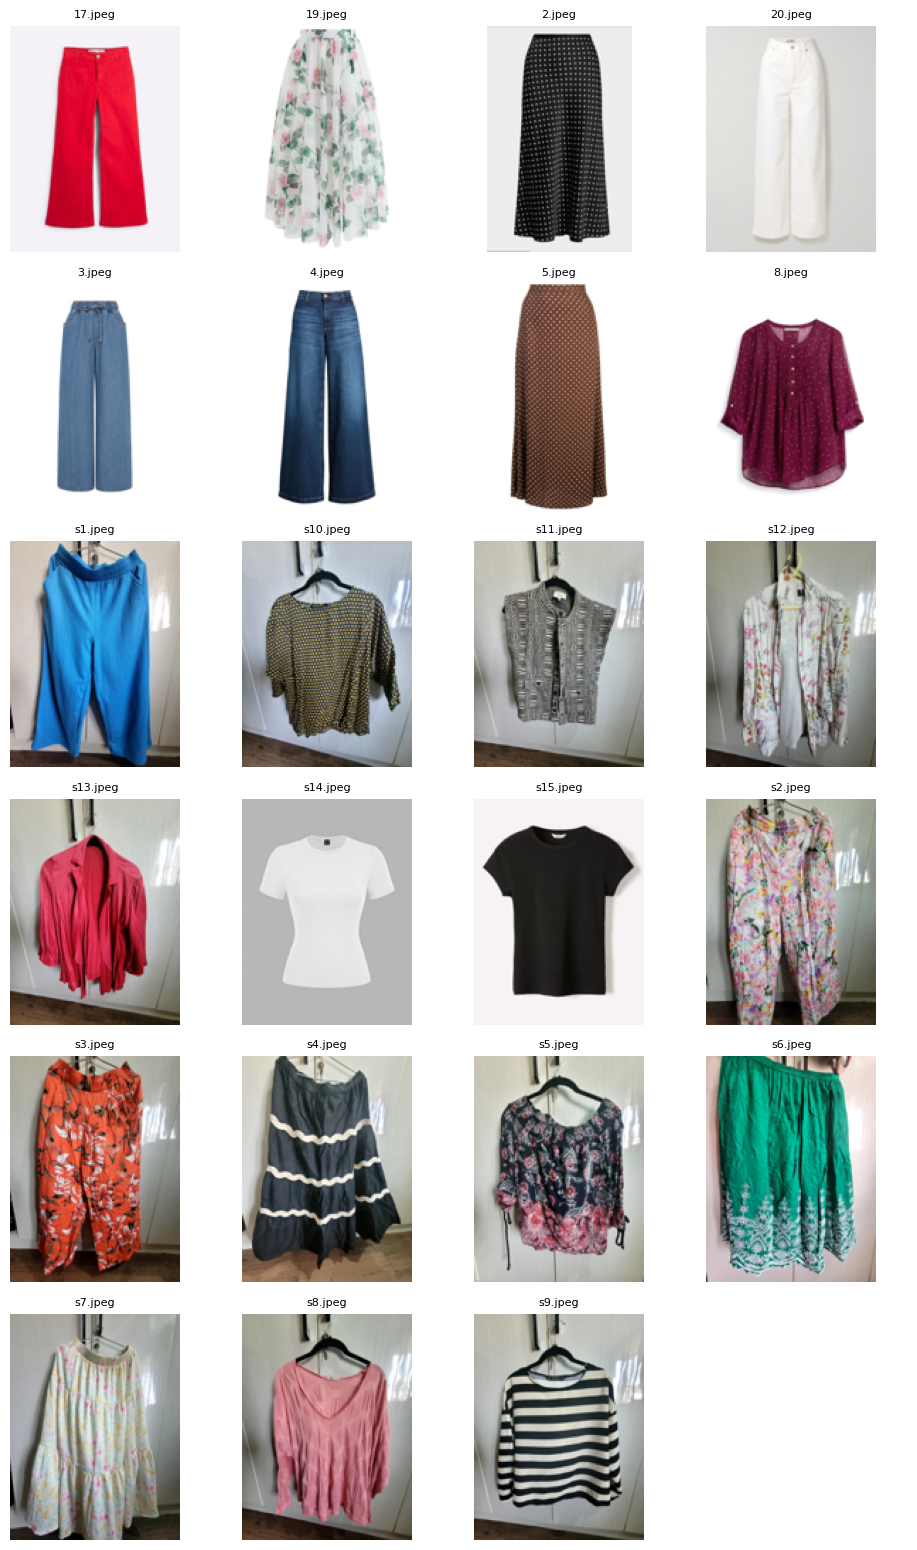

In [29]:
import math
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt


def show_image_grid(
    folder: str | Path,
    *,
    ncols: int = 4,
    thumb: int = 160,
    extensions: set[str] | None = None,
) -> None:
    folder = Path(folder).expanduser().resolve()
    if extensions is None:
        extensions = {".jpg", ".jpeg", ".png", ".webp", ".gif", ".bmp"}

    paths = sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in extensions
    )
    if not paths:
        print(f"No images in {folder}")
        return

    n = len(paths)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.4, nrows * 2.6))
    if nrows == 1 and ncols == 1:
        axes_list = [axes]
    else:
        axes_list = axes.flatten()

    for i, ax in enumerate(axes_list):
        if i < n:
            p = paths[i]
            im = Image.open(p).convert("RGB")
            im.thumbnail((thumb, thumb))
            ax.imshow(im)
            ax.set_title(p.name, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Example — use your notebook’s IMAGES_DIR or any path:
show_image_grid(IMAGES_DIR, ncols=4, thumb=160)

## 1 Get Image Metadata

In [31]:
# Function Definition

def extract_clothing_metadata(
    image_path: str | Path,
    *,
    provider: Literal["openai", "anthropic", "openrouter"],
    model: str,
    temperature: float = 0.2,
) -> dict[str, Any]:
    path = Path(image_path).expanduser().resolve()
    if not path.is_file():
        raise FileNotFoundError(path)

    user_text = "Analyze this clothing item and fill the JSON schema."

    if provider in ("openai", "openrouter"):
        if provider == "openai":
            client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
        else:
            default_headers = {
                "X-Title": os.environ.get("OPENROUTER_APP_TITLE", "Fashion metadata extraction"),
            }
            referer = os.environ.get("OPENROUTER_HTTP_REFERER")
            if referer:
                default_headers["HTTP-Referer"] = referer
            client = OpenAI(
                api_key=os.environ["OPENROUTER_API_KEY"],
                base_url="https://openrouter.ai/api/v1",
                default_headers=default_headers,
            )
        data_url = _data_url(path)
        response = client.chat.completions.create(
            model=model,
            temperature=temperature,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": EXTRACTION_SYSTEM},
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": user_text},
                        {"type": "image_url", "image_url": {"url": data_url}},
                    ],
                },
            ],
        )
        out = response.choices[0].message.content
        if not out:
            raise ValueError("Empty response from model")
        return json.loads(out)

    if provider == "anthropic":
        import anthropic

        raw, media_type = _image_bytes_and_mime(path)
        b64 = base64.standard_b64encode(raw).decode("ascii")
        oauth = os.environ.get("ANTHROPIC_AUTH_TOKEN")
        api_key = os.environ.get("ANTHROPIC_API_KEY")
        if oauth and api_key:
            raise ValueError(
                "Set only one of ANTHROPIC_AUTH_TOKEN (OAuth) or ANTHROPIC_API_KEY, not both."
            )
        if oauth:
            client = anthropic.Anthropic(auth_token=oauth)
        elif api_key:
            client = anthropic.Anthropic(api_key=api_key)
        else:
            raise ValueError(
                "Set ANTHROPIC_AUTH_TOKEN (OAuth bearer token) or ANTHROPIC_API_KEY in the environment."
            )
        message = client.messages.create(
            model=model,
            max_tokens=4096,
            temperature=temperature,
            system=EXTRACTION_SYSTEM,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": media_type,
                                "data": b64,
                            },
                        },
                        {"type": "text", "text": user_text},
                    ],
                }
            ],
        )
        text_parts: list[str] = []
        for block in message.content:
            if block.type == "text":
                text_parts.append(block.text)
        combined = "".join(text_parts).strip()
        if not combined:
            raise ValueError("Empty response from model")
        return _parse_json_loose(combined)

    raise ValueError(f"Unknown provider: {provider}")

In [32]:
# PROMPT

EXTRACTION_SYSTEM = """You are a fashion analysis system. Analyze the clothing item in the image and extract detailed attributes useful for outfit recommendation and compatibility.

Return ONLY valid JSON. No explanation.

Guidelines:
- Be descriptive but concise
- Prefer lists over single values where appropriate
- Do not hallucinate brand names
- If unsure, give best visual estimate
- Keep notes short

Schema:
{
  "type": string,
  "category": one of ["top","bottom","footwear","outerwear","full_body","accessory"],

  "colors": {
    "primary": string,
    "secondary": [string],
    "all": [string]
  },

  "visual_attributes": {
    "pattern": string,
    "pattern_density": one of ["low","medium","high"],
    "texture": string,
    "material": string,
    "finish": string
  },

  "shape_fit": {
    "fit": one of ["slim","regular","relaxed","oversized"],
    "silhouette": string,
    "length": string,
    "structure": string
  },

  "style": {
    "formality": float (0 casual → 1 formal),
    "style_tags": [string],
    "aesthetic": [string],
    "occasion_suitability": [string]
  },

  "seasonality": {
    "season": [string],
    "weather": [string]
  },

  "pairing_hints": {
    "goes_well_with": [string],
    "avoid_with": [string],
    "color_pairing_suggestions": [string]
  },

  "metadata": {
    "gender_suggestion": string,
    "age_group": string
  },

  "notes": short string (max 12 words)
}
"""

In [33]:
PROVIDER: Literal["openai", "anthropic", "openrouter"] = "openrouter"
MODEL = "google/gemini-3.1-flash-image-preview"
IMAGES_DIR = ROOT / "images"
METADATA_DIR = ROOT / "metadata"
ensure_project_dirs(ROOT)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".gif", ".bmp"}


def iter_images(folder: Path) -> list[Path]:
    if not folder.is_dir():
        raise FileNotFoundError(f"Create folder and add photos: {folder}")
    return sorted(
        p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )


for img_path in iter_images(IMAGES_DIR):
    meta = extract_clothing_metadata(img_path, provider=PROVIDER, model=MODEL)
    payload = {"filename": img_path.name, **meta}
    out_path = METADATA_DIR / f"{img_path.stem}.json"
    out_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    print("wrote", out_path)


wrote /Users/mohitjoshi/Projects/fashion-app/notebooks/metadata/17.json


KeyboardInterrupt: 

## 2. Outfit combinations (text LLM)


In [60]:
eval_set = [
{
    "user_query": "Season: Summer, Occassion: Office Wear",
    "valid_combinations": [
        ["19", "s13", "s14"],
        ["s2", "s15"],
        ["s2", "s15", "s13"],
        ["s2", "s14", "s13"],
        ["20", "s9"],
        ["20", "s12", "s14"],
        ["20", "s14", "s11"],
        ["s5", "s14"],
        ["s12", "s14", "s1"],
        ["s3", "s12", "s14"]
     ]
},
{
    "user_query": "Season: Spring, Occassion: Casual Wear",
    "valid_combinations": [
        ["s7", "s14"],
        ["19", "s14"],
        ["19", "s8"],
        ["s2", "s14"],
        ["s8", "s2"],
        ["s3", "s14"],
        ["s4", "s15"],
        ["s4", "s14"],
        ["20", "8"]
    ]
},
{
   "user_query": "Season: Autumn, Occassion: Party Wear",
    "valid_combinations": [
        ["2", "s13", "s15"],
        ["5", "s14", "s11"],
        ["5", "s15"],
        ["19", "8"],
        ["s10", "4"],
        ["s6", "s13", "s14"],
        ["s9", "17"]
    ] 
}
]

In [61]:
OUTFIT_SYSTEM = """You are an expert fashion stylist. Input includes `user_query` and `wardrobe`: a JSON array where each item has `filename` and extracted attributes (`category`, colors, `style`, etc.).

Task:
- Build outfit combinations from `wardrobe` that match `user_query`.
- **Bottom**: exactly one filename in `bottom` (lower body: `bottom`, `footwear`, or similar).
- **Top / upper body**: assign `top` as either:
  - a **single string** filename (one upper garment), OR
  - a **JSON array of strings** (multiple filenames) ordered **outer layer → inner** when layering fits (e.g. jacket over shirt, coat over sweater). Use categories (`outerwear`, `top`, etc.) to order layers sensibly.
- Layering may combine outerwear + top; do not duplicate a filename in one combination.
- Skip `accessory`-only looks unless the query implies it; do not pair two accessories alone.
- Do not combine a `full_body` one-piece with other garments in the same outfit (one-piece stands alone).

Score each combination from 0.0–1.0 for (a) relevance to `user_query` and (b) fashion coherence (color, formality, silhouette, layering).

For **every** combination you **must** include **`reasons`**: a JSON array of **at least one** short string explaining why the outfit fits the query and why the score is justified (cite concrete attributes from the wardrobe items when useful).

Return ONLY valid JSON:
{"combinations": [{"top": "<filename OR [filenames...]>", "bottom": "<filename>", "score": <number>, "reasons": ["<string>", "..."]}]}

`top` must be either a string or an array of strings. `reasons` must be a **non-empty** array of strings. Filenames must match `wardrobe` exactly. Sort by descending `score`. If no valid combination exists, return {"combinations": []}.
"""


In [46]:
# USER_QUERY = "Semi formal office wear"

In [62]:

def _normalize_outfit_combination(c: dict[str, Any]) -> dict[str, Any]:
    """Require non-empty `reasons` (list[str] or single str); return a copy with normalized `reasons`."""
    if not isinstance(c, dict):
        raise ValueError(f"Each combination must be an object, got {type(c)}")
    raw = c.get("reasons")
    if raw is None:
        raise ValueError(f"Missing required 'reasons' (≥1 string): {c!r}")
    if isinstance(raw, str):
        reasons = [raw.strip()] if raw.strip() else []
    elif isinstance(raw, list):
        reasons = [str(x).strip() for x in raw if str(x).strip()]
    else:
        raise ValueError(f"'reasons' must be str or list[str], got {type(raw)}: {c!r}")
    if not reasons:
        raise ValueError(f"'reasons' must contain at least one non-empty string: {c!r}")
    out = dict(c)
    out["reasons"] = reasons
    return out


def suggest_outfit_combinations(
    wardrobe: list[dict[str, Any]],
    user_query: str,
    *,
    provider: Literal["openai", "openrouter", "anthropic"],
    model: str,
    temperature: float = 0.3,
) -> list[dict[str, Any]]:
    """Returns list of dicts: top, bottom, score, reasons (non-empty list[str])."""
    user = json.dumps(
        {"user_query": user_query, "wardrobe": wardrobe},
        ensure_ascii=False,
        indent=2,
    )
    out = text_completion_json_object(
        provider=provider,
        model=model,
        system=OUTFIT_SYSTEM,
        user=user,
        temperature=temperature,
    )
    combos = out.get("combinations", [])
    if not isinstance(combos, list):
        raise ValueError("Expected combinations array in model output")
    return combos


In [63]:
wardrobe = load_wardrobe_from_metadata_dir(METADATA_DIR)
if not wardrobe:
    raise RuntimeError(f"No JSON in {METADATA_DIR}; run section 1 first.")

In [67]:
import json
import uuid
from datetime import datetime, timezone
from pathlib import Path
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
def _stems_from_model_combo(combo: dict) -> frozenset[str]:
    t = combo.get("top")
    tops = [t] if isinstance(t, str) else list(t)
    stems = [Path(str(x)).stem for x in tops]
    stems.append(Path(str(combo["bottom"])).stem)
    return frozenset(stems)
def _stems_from_gold(gold: list) -> frozenset[str]:
    return frozenset(str(x) for x in gold)
def combo_in_eval_set(combo: dict, valid_combinations: list[list]) -> int:
    pred = _stems_from_model_combo(combo)
    for g in valid_combinations:
        if pred == _stems_from_gold(g):
            return 1
    return 0
def _gold_lists_for_query(uq: str, eval_set_local: list[dict]) -> list[list]:
    for x in eval_set_local:
        if x["user_query"] == uq:
            return x["valid_combinations"]
    raise KeyError(f"No eval_set entry for user_query={uq!r}")
# --- write eval JSONL ---
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S") + "_" + uuid.uuid4().hex[:8]
PROMPT_LABEL = "baseline-gemma26b"
EVAL_JSONL = Path("outputs") / "eval_combinations.jsonl"
EVAL_JSONL.parent.mkdir(parents=True, exist_ok=True)
OUTFIT_TEXT_PROVIDER: Literal["openai", "openrouter", "anthropic"] = "openrouter"
OUTFIT_TEXT_MODEL = "google/gemma-4-26b-a4b-it"
eval_out: list[dict] = []
COMBINATIONS_BY_QUERY: list[tuple[str, list[dict]]] = []
for ex in eval_set:
    uq = ex["user_query"]
    gold = ex["valid_combinations"]
    combinations = suggest_outfit_combinations(
        wardrobe,
        uq,
        provider=OUTFIT_TEXT_PROVIDER,
        model=OUTFIT_TEXT_MODEL,
    )
    COMBINATIONS_BY_QUERY.append((uq, list(combinations)))
    # optional: persist raw model output per query (valid Python)
    COMBINATIONS_PATH = Path("outputs") / f"combinations_{abs(hash(uq))}.json"
    COMBINATIONS_PATH.write_text(json.dumps(combinations, ensure_ascii=False, indent=2), encoding="utf-8")
    with EVAL_JSONL.open("a", encoding="utf-8") as jlf:
        for c in combinations:
            rec = {
                "run_id": RUN_ID,
                "prompt_label": PROMPT_LABEL,
                "user_query": uq,
                "combination": c,
                "in_eval_set": combo_in_eval_set(c, gold),
            }
            eval_out.append(rec)
            jlf.write(json.dumps(rec, ensure_ascii=False) + "\n")
print("run_id:", RUN_ID, "records:", len(eval_out), "jsonl:", EVAL_JSONL.resolve())


run_id: 20260405T124534_dbe2bcfb records: 19 jsonl: /Users/mohitjoshi/Projects/fashion-app/notebooks/outputs/eval_combinations.jsonl


,run_id,prompt_label,user_query,n_preds,n_hits,pred_hit_rate,gold_recall
0,20260405T103330_25c6c3f3,baseline,"Season: Autumn, Occassion: Party Wear",4,0,0.0000,0.0000
1,20260405T103330_25c6c3f3,baseline,"Season: Spring, Occassion: Casual Wear",5,0,0.0000,0.0000
2,20260405T103330_25c6c3f3,baseline,"Season: Summer, Occassion: Office Wear",4,1,0.2500,0.2000
3,20260405T105310_97ae8bd2,baseline,"Season: Autumn, Occassion: Party Wear",4,0,0.0000,0.0000
4,20260405T105310_97ae8bd2,baseline,"Season: Spring, Occassion: Casual Wear",6,0,0.0000,0.0000
5,20260405T105310_97ae8bd2,baseline,"Season: Summer, Occassion: Office Wear",4,1,0.2500,0.1000
6,20260405T113542_cb9b0551,baseline,"Season: Autumn, Occassion: Party Wear",3,0,0.0000,0.0000
7,20260405T113542_cb9b0551,baseline,"Season: Spring, Occassion: Casual Wear",5,0,0.0000,0.0000
8,20260405T113542_cb9b0551,baseline,"Season: Summer, Occassion: Office Wear",5,0,0.0000,0.1000
9,20260405T121407_e281538c,baseline-data-update,"Season: Autumn, Occassion: Party Wear",3,1,0.3333,0.1429


,run_id,prompt_label,mean_pred_hit_rate,mean_gold_recall,total_preds,total_hits
0,20260405T103330_25c6c3f3,baseline,0.0833,0.0667,13,1
1,20260405T105310_97ae8bd2,baseline,0.0833,0.0333,14,1
2,20260405T113542_cb9b0551,baseline,0.0000,0.0333,13,0
3,20260405T121407_e281538c,baseline-data-update,0.1111,0.0476,13,1
4,20260405T124534_dbe2bcfb,baseline-gemma26b,0.0370,0.0370,19,1


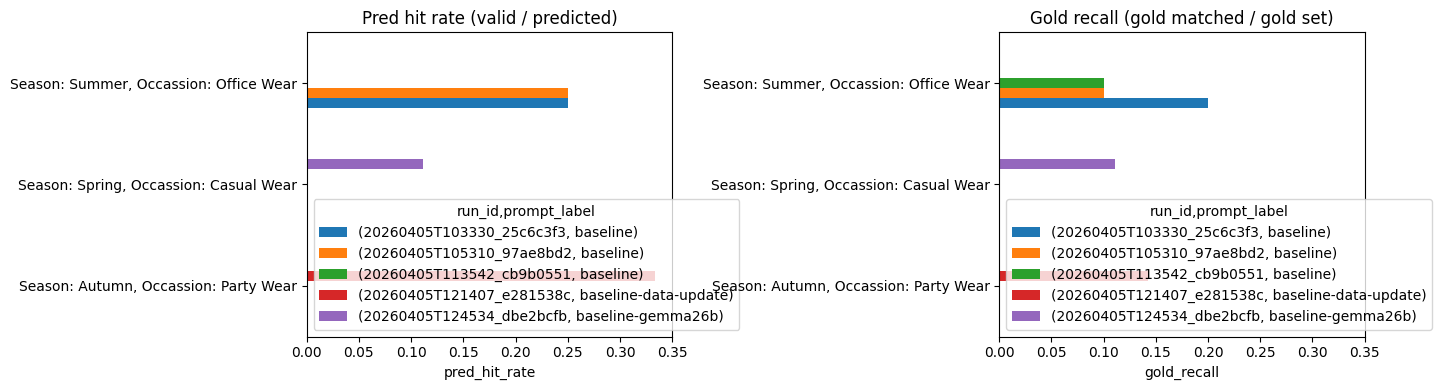

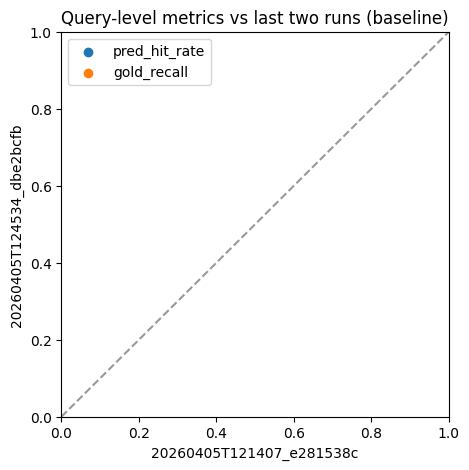

In [68]:
# --- load all runs ---
import json
from pathlib import Path

def _iter_jsonl_objects(path: Path):
    """One JSON object per line; also splits multiple root objects glued on one line (missing newline)."""
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except json.JSONDecodeError:
                start = 0
                depth = 0
                in_str = False
                esc = False
                for i, ch in enumerate(line):
                    if esc:
                        esc = False
                        continue
                    if in_str:
                        if ch == "\\":
                            esc = True
                        elif ch == '"':
                            in_str = False
                        continue
                    if ch == '"':
                        in_str = True
                        continue
                    if ch == "{":
                        depth += 1
                    elif ch == "}":
                        depth -= 1
                        if depth == 0:
                            chunk = line[start : i + 1].strip()
                            if chunk:
                                yield json.loads(chunk)
                            start = i + 1
                rest = line[start:].strip()
                if rest:
                    yield json.loads(rest)


df = pd.DataFrame(list(_iter_jsonl_objects(EVAL_JSONL)))
if df.empty:
    raise SystemExit("No rows in JSONL yet")

# precision@predictions: fraction of model combos that are valid
hit = df.groupby(["run_id", "prompt_label", "user_query"], as_index=False).agg(
    n_preds=("in_eval_set", "size"),
    n_hits=("in_eval_set", "sum"),
)
hit["pred_hit_rate"] = hit["n_hits"] / hit["n_preds"].clip(lower=1)


def gold_recall_for_row(row, eval_set_local: list[dict]) -> float:
    uq = row["user_query"]
    run_id = row["run_id"]
    plab = row["prompt_label"]
    gold_lists = next(x["valid_combinations"] for x in eval_set_local if x["user_query"] == uq)
    gold_sets = [_stems_from_gold(g) for g in gold_lists]
    sub = df[
        (df.run_id == run_id)
        & (df.prompt_label == plab)
        & (df.user_query == uq)
    ]
    pred_sets = [_stems_from_model_combo(c) for c in sub["combination"]]
    if not gold_sets:
        return float("nan")
    matched = sum(1 for g in gold_sets if g in pred_sets)
    return matched / len(gold_sets)


hit["gold_recall"] = hit.apply(lambda r: gold_recall_for_row(r, eval_set), axis=1)

display(hit.round(4))

# --- summary per run (+ prompt_label) ---
run_summary = hit.groupby(["run_id", "prompt_label"], as_index=False).agg(
    mean_pred_hit_rate=("pred_hit_rate", "mean"),
    mean_gold_recall=("gold_recall", "mean"),
    total_preds=("n_preds", "sum"),
    total_hits=("n_hits", "sum"),
)
display(run_summary.round(4))

# --- bar chart: per query, two metrics, faceted by run_id ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

for ax, col, title in zip(
    axes,
    ["pred_hit_rate", "gold_recall"],
    ["Pred hit rate (valid / predicted)", "Gold recall (gold matched / gold set)"],
):
    pivot = hit.pivot_table(
        index="user_query",
        columns=["run_id", "prompt_label"],
        values=col,
        aggfunc="first",
    )
    pivot.plot(kind="barh", ax=ax, legend=True)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# --- optional: scatter variance across queries for two runs (after you have 2+ run_ids) ---
# Compare same prompt_label across runs, or two prompt_labels in one run — tweak filter as needed.
runs = df["run_id"].unique()
if len(runs) >= 2:
    r1, r2 = runs[-2], runs[-1]
    pl = df["prompt_label"].iloc[0]
    h1 = hit[(hit.run_id == r1) & (hit.prompt_label == pl)].set_index("user_query")
    h2 = hit[(hit.run_id == r2) & (hit.prompt_label == pl)].set_index("user_query")
    m = h1[["pred_hit_rate", "gold_recall"]].join(
        h2[["pred_hit_rate", "gold_recall"]], rsuffix="_2", how="inner"
    )
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(m["pred_hit_rate"], m["pred_hit_rate_2"], label="pred_hit_rate")
    ax.scatter(m["gold_recall"], m["gold_recall_2"], label="gold_recall")
    lim = 0, 1
    ax.plot(lim, lim, "k--", alpha=0.4)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel(r1)
    ax.set_ylabel(r2)
    ax.set_title(f"Query-level metrics vs last two runs ({pl})")
    ax.legend()
    plt.show()

/var/folders/55/4w3w11vn1pdfybhjcst03tz80000gp/T/ipykernel_91901/983954847.py:79: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


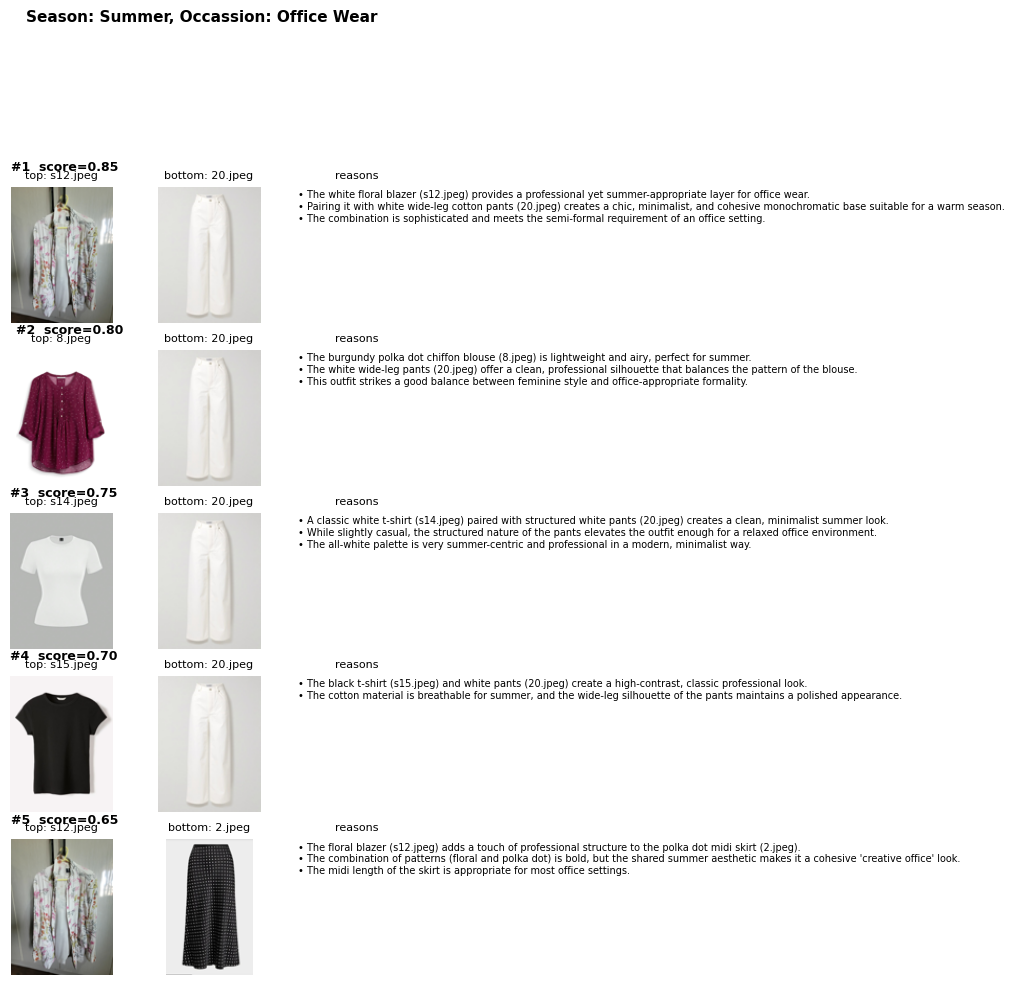

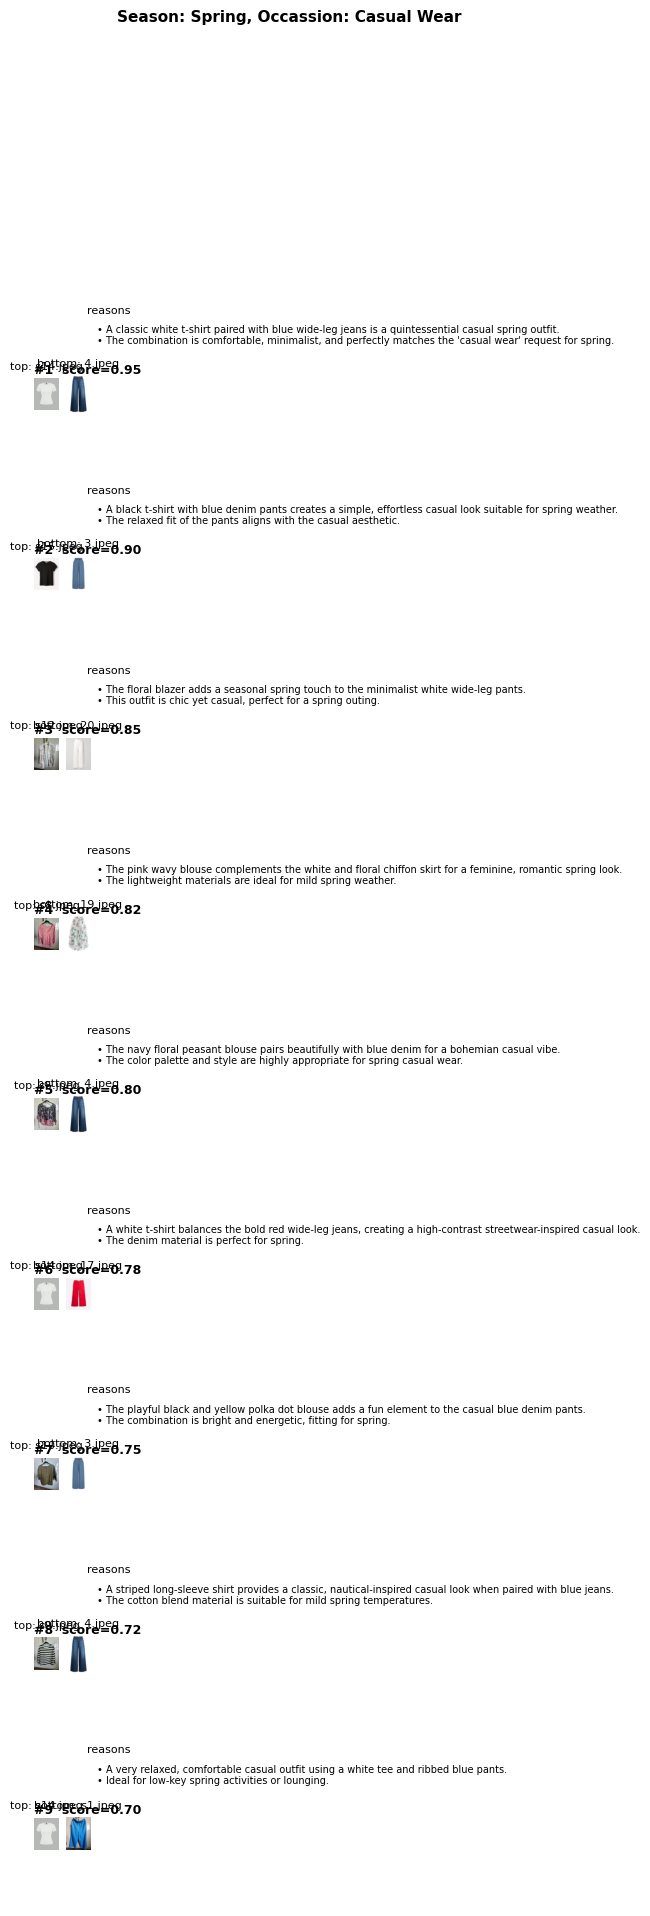

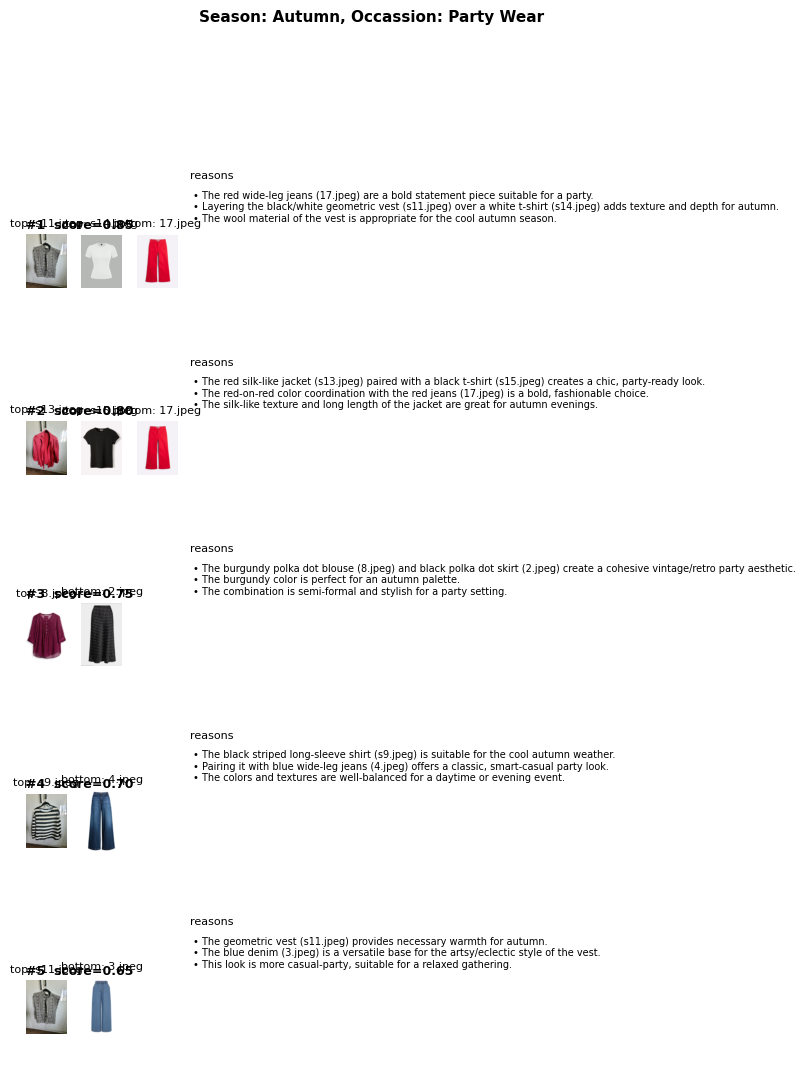

In [69]:
import textwrap
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image


def _top_filenames(combo: dict) -> list[str]:
    t = combo["top"]
    if isinstance(t, list):
        return [str(x) for x in t]
    return [str(t)]


def show_outfit_combinations_grid(
    combinations: list[dict] | dict,
    images_dir: str | Path,
    *,
    thumb: int = 130,
    user_query: str | None = None,
) -> None:
    """Plot outfits in rows. Pass ``user_query`` to label which prompt produced these combos."""
    images_dir = Path(images_dir).expanduser().resolve()
    if isinstance(combinations, dict):
        combinations = [combinations]
    if not combinations:
        print("No combinations to show")
        return

    max_slots = max(len(_top_filenames(c)) + 1 for c in combinations)  # tops + bottom
    n = len(combinations)
    reason_cols = 1
    ncols = max_slots + reason_cols
    extra_h = 0.6 if user_query else 0.0

    fig, axes = plt.subplots(n, ncols, figsize=(ncols * 1.8, n * 2.1 + extra_h), squeeze=False)
    if user_query:
        fig.suptitle(
            textwrap.fill(user_query, width=100),
            fontsize=11,
            fontweight="bold",
        )

    for i, combo in enumerate(combinations):
        tops = _top_filenames(combo)
        bot = str(combo["bottom"])
        paths = [images_dir / name for name in tops] + [images_dir / bot]
        labels = [f"top: {name}" for name in tops] + [f"bottom: {bot}"]
        score = float(combo.get("score", 0))

        for j in range(max_slots):
            ax = axes[i, j]
            ax.axis("off")
            if j < len(paths):
                p = paths[j]
                if p.is_file():
                    im = Image.open(p).convert("RGB")
                    im.thumbnail((thumb, thumb))
                    ax.imshow(im)
                    ax.set_title(labels[j], fontsize=8)
                else:
                    ax.text(0.5, 0.5, f"missing\n{p.name}", ha="center", va="center", fontsize=8)

        ax_r = axes[i, max_slots]
        ax_r.axis("off")
        reasons = combo.get("reasons") or []
        if reasons:
            body = "\n".join(f"• {r}" for r in reasons)
            ax_r.text(0.02, 0.98, body, va="top", ha="left", fontsize=7)
        ax_r.set_title("reasons", fontsize=8)

        axes[i, 0].annotate(
            f"#{i + 1}  score={score:.2f}",
            xy=(0, 1.12),
            xycoords="axes fraction",
            fontsize=9,
            fontweight="bold",
        )

    plt.tight_layout()
    plt.subplots_adjust(top=0.82 if user_query else 0.92)
    plt.show()


# --- run ---
# Prefer COMBINATIONS_BY_QUERY from the eval cell (one figure per query, titled with the prompt).
_pairs = globals().get("COMBINATIONS_BY_QUERY")
if _pairs:
    for uq, combos in _pairs:
        show_outfit_combinations_grid(combos, IMAGES_DIR, thumb=130, user_query=uq)
else:
    show_outfit_combinations_grid(combinations, IMAGES_DIR, thumb=130, user_query=None)


## Evals

## 3a. Preview — instruction builder (`outfit_image_prompt_for_generation`)


In [18]:
def outfit_image_prompt_for_generation(*, include_person_reference: bool) -> str:
    """Build instructions for the image model (identity preservation vs generic model)."""
    if include_person_reference:
        person = (
            "The first reference image is a photo of a real person. "
            "In the output, preserve that person's facial identity, skin tone, hair, and visible body proportions; do not substitute a different person. "
            "Dress that same individual in the garments shown in the later reference images."
        )
    else:
        person = (
            "No person reference image is provided. "
            "Depict a single plausible generic adult fashion model (professional, neutral appearance)."
        )
    garments = (
        "After any person photo, the remaining references are garments only, in order: "
        "upper-body pieces from OUTER layer to INNER (e.g. jacket then shirt), then the lower-body garment last. "
        "Match colors, patterns, and silhouette from those references."
    )
    out = (
        "Output exactly ONE photorealistic full-body fashion photograph: clean studio lighting, neutral background, natural standing pose, editorial quality."
    )
    return "\n\n".join([person, garments, out])



## 3b. Preview — `generate_outfit_preview_images`


In [19]:


def _outfit_prompt_with_reasons(base_prompt: str, combo: dict[str, Any]) -> str:
    """Append model `reasons` to the image prompt when present."""
    reasons = combo.get("reasons") or []
    if not reasons:
        return base_prompt
    bullet = "\n".join(f"- {r}" for r in reasons)
    return f"{base_prompt}\n\nStylist reasoning (honor when composing the outfit):\n{bullet}"


def _write_outfit_meta(image_path: Path, combo: dict[str, Any]) -> None:
    """Sidecar JSON next to each rendered outfit (score, top, bottom, reasons)."""
    meta = {
        "score": float(combo.get("score", 0)),
        "top": combo.get("top"),
        "bottom": combo.get("bottom"),
        "reasons": combo.get("reasons", []),
    }
    meta_path = image_path.parent / f"{image_path.stem}_meta.json"
    meta_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

def _normalize_top_filenames(combo: dict[str, Any]) -> list[str]:
    """`top` may be a string or a list of strings (layering order: outer → inner)."""
    t = combo.get("top")
    if isinstance(t, list):
        return [str(x).strip() for x in t if str(x).strip()]
    if isinstance(t, str) and t.strip():
        return [t.strip()]
    return []


def generate_outfit_preview_images(
    combinations: list[dict[str, Any]],
    *,
    images_dir: Path,
    outfit_image_prompt: str,
    person_image_path: Path | None = None,
    min_score: float,
    top_k: int,
    out_dir: Path,
    provider: Literal["openai", "openrouter", "anthropic"] = "openai",
    model: str = "gpt-image-1.5",
    image_config: dict[str, Any] | None = None,
    append_reasons_to_prompt: bool = True,
    write_meta: bool = True,
) -> list[Path]:
    """Reference image order: optional person, upper garments (outer→inner), then lower garment.

    When ``append_reasons_to_prompt`` is True, each combo's ``reasons`` are appended to the text prompt
    for OpenRouter / OpenAI image calls. When ``write_meta`` is True, writes ``<stem>_meta.json`` beside each PNG.
    """
    if provider == "anthropic":
        raise ValueError("provider='anthropic' is not supported for outfit preview images.")

    ranked = [c for c in combinations if float(c.get("score", 0)) >= min_score]
    ranked.sort(key=lambda c: float(c.get("score", 0)), reverse=True)
    ranked = ranked[:top_k]

    out_dir.mkdir(parents=True, exist_ok=True)
    saved: list[Path] = []

    if provider == "openai":
        client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

    for i, combo in enumerate(ranked):
        bot_n = combo.get("bottom")
        tops = _normalize_top_filenames(combo)
        if not tops or not bot_n:
            continue
        bot_path = images_dir / str(bot_n)
        top_paths = [images_dir / n for n in tops]
        if not bot_path.is_file():
            print("skip missing bottom:", bot_path)
            continue
        if not all(p.is_file() for p in top_paths):
            print("skip missing top file in:", top_paths)
            continue

        person_path = person_image_path if person_image_path and person_image_path.is_file() else None
        ref_paths: list[Path] = []
        if person_path:
            ref_paths.append(person_path)
        ref_paths.extend(top_paths)
        ref_paths.append(bot_path)

        path = out_dir / f"outfit_{i:02d}_{float(combo.get('score',0)):.2f}.png"

        eff_prompt = (
            _outfit_prompt_with_reasons(outfit_image_prompt, combo)
            if append_reasons_to_prompt
            else outfit_image_prompt
        )

        if provider == "openrouter":
            png = _openrouter_chat_image_generation(
                model=model,
                reference_image_paths=ref_paths,
                prompt=eff_prompt,
                image_config=image_config,
            )
            path.write_bytes(png)
            if write_meta:
                _write_outfit_meta(path, combo)
            saved.append(path)
            print("wrote", path)
            continue

        with contextlib.ExitStack() as stack:
            files = [stack.enter_context(open(p, "rb")) for p in ref_paths]
            resp = client.images.edit(
                model=model,
                image=files,
                prompt=eff_prompt,
            )
        data = resp.data[0]
        if getattr(data, "b64_json", None):
            path.write_bytes(base64.standard_b64decode(data.b64_json))
        elif getattr(data, "url", None):
            urllib.request.urlretrieve(data.url, str(path))
        else:
            raise ValueError("Image response had neither url nor b64_json")
        if write_meta:
            _write_outfit_meta(path, combo)
        saved.append(path)
        print("wrote", path)

    return saved



## 3c. Preview — run


In [20]:
SCORE_MIN = 0.7
TOP_K = 2
IMAGE_GEN_PROVIDER: Literal["openai", "openrouter", "anthropic"] = "openrouter"
IMAGE_GEN_MODEL = "google/gemini-3.1-flash-image-preview"
IMAGE_GEN_CONFIG: dict | None = {"aspect_ratio": "3:4", "image_size": "1K"}

# Optional: photo of the person to dress (omit file or use a non-existent path for a generic model)
PERSON_IMAGE_PATH = ROOT / "person" / "person.jpeg"

OUTFIT_IMAGES_DIR = ROOT / "outputs" / "outfit_previews"
ensure_project_dirs(ROOT)

COMBINATIONS_PATH = ROOT / "outputs" / "combinations.json"
wardrobe = load_wardrobe_from_metadata_dir(METADATA_DIR)
combinations = json.loads(COMBINATIONS_PATH.read_text(encoding="utf-8"))

include_person = PERSON_IMAGE_PATH.is_file()
outfit_prompt = outfit_image_prompt_for_generation(include_person_reference=include_person)

saved_paths = generate_outfit_preview_images(
    combinations,
    images_dir=IMAGES_DIR,
    outfit_image_prompt=outfit_prompt,
    person_image_path=PERSON_IMAGE_PATH if include_person else None,
    min_score=SCORE_MIN,
    top_k=TOP_K,
    out_dir=OUTFIT_IMAGES_DIR,
    provider=IMAGE_GEN_PROVIDER,
    model=IMAGE_GEN_MODEL,
    image_config=IMAGE_GEN_CONFIG,
)
saved_paths


wrote /Users/mohitjoshi/Projects/fashion-app/notebooks/outputs/outfit_previews/outfit_00_0.80.png
wrote /Users/mohitjoshi/Projects/fashion-app/notebooks/outputs/outfit_previews/outfit_01_0.70.png


[PosixPath('/Users/mohitjoshi/Projects/fashion-app/notebooks/outputs/outfit_previews/outfit_00_0.80.png'),
 PosixPath('/Users/mohitjoshi/Projects/fashion-app/notebooks/outputs/outfit_previews/outfit_01_0.70.png')]

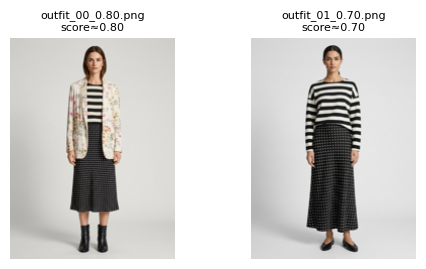

In [27]:
import math
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt


def show_generated_outfits_grid(
    paths_or_folder: list | str | Path,
    *,
    thumb: int = 220,
    ncols: int | None = None,
) -> None:
    """
    Show generated preview images in a grid with filename (and score if encoded like outfit_00_0.80.png).
    Pass a folder path, or a list of paths (e.g. `saved_paths` from `generate_outfit_preview_images`).
    """
    if isinstance(paths_or_folder, (str, Path)):
        folder = Path(paths_or_folder).expanduser().resolve()
        paths = sorted(
            p for p in folder.iterdir()
            if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg", ".webp"}
        )
    else:
        paths = [Path(p).expanduser().resolve() for p in paths_or_folder]

    paths = [p for p in paths if p.is_file()]
    if not paths:
        print("No generated images to show")
        return

    n = len(paths)
    ncols = ncols or min(4, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.6, nrows * 2.8), squeeze=False)
    axes_list = axes.flatten()

    for i, ax in enumerate(axes_list):
        ax.axis("off")
        if i >= n:
            continue
        p = paths[i]
        im = Image.open(p).convert("RGB")
        im.thumbnail((thumb, thumb))
        ax.imshow(im)
        # Title: filename; subtitle hint if name looks like outfit_XX_0.80.png
        stem = p.stem
        parts = stem.split("_")
        extra = ""
        if len(parts) >= 3 and parts[0] == "outfit":
            try:
                extra = f"\nscore≈{float(parts[-1]):.2f}"
            except ValueError:
                pass
        ax.set_title(f"{p.name}{extra}", fontsize=8)

    plt.tight_layout()
    plt.show()


# --- run (pick one) ---
# show_generated_outfits_grid(saved_paths)
# show_generated_outfits_grid(OUTFIT_IMAGES_DIR)
show_generated_outfits_grid(ROOT / "outputs" / "outfit_previews")